In [1]:
import random
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import re

from keras.layers import TextVectorization,Embedding,Dense,SimpleRNN,Dropout,Lambda
from keras.models import Sequential
from keras.optimizers import Adam

from sklearn.model_selection import train_test_split

2024-01-06 22:08:58.946480: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [3]:
df = pd.read_csv('imdb.csv')

In [4]:
def clean(text):
    result = text.lower()
    result = re.sub(r'<[^>]*>', r' ', result)
    result = re.sub(r'[^a-z0-9\s\']', r' ', result)
    result = re.sub(r'\s+', r' ', result)
    return result

df['Cleaned'] = df['Review'].apply(clean)
df['Tokens'] = df['Cleaned'].apply(lambda x: len(x.split()))

<Axes: >

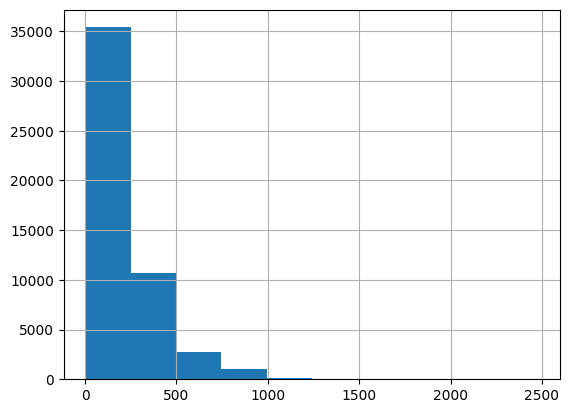

In [5]:
df['Tokens'].hist()